# 소방청 화재발생 통계 × 인구 데이터 분석 프로젝트

## 0단계 - 데이터 소스 선정 및 검증

In [1]:
import pandas as pd
import numpy as np
import re

### 1.1 화재 데이터 로드

In [2]:
fire = pd.read_csv(r'C:\data\소방청_화재발생_정보_20241231.csv', encoding='cp949')
print(f'행 : {fire.shape[0]}, 열 : {fire.shape[1]}')

행 : 191510, 열 : 15


### 1.2 구조 파악

In [3]:
print(fire.info())
print('시도(', fire['시도'].nunique(), '개) :', sorted(fire['시도'].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191510 entries, 0 to 191509
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   화재발생년원일    191510 non-null  object 
 1   시도         191510 non-null  object 
 2   시군구        191510 non-null  object 
 3   화재유형       191510 non-null  object 
 4   발화요인대분류    191510 non-null  object 
 5   발화요인소분류    191510 non-null  object 
 6   인명피해(명)소계  191510 non-null  int64  
 7   사망         191510 non-null  int64  
 8   부상         191510 non-null  int64  
 9   재산피해소계     191510 non-null  int64  
 10  부동산        176440 non-null  float64
 11  동산         176440 non-null  float64
 12  장소대분류      191510 non-null  object 
 13  장소중분류      191510 non-null  object 
 14  장소소분류      191510 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 21.9+ MB
None
시도( 17 개) : ['강원특별자치도', '경기도', '경상남도', '경상북도', '광주광역시', '대구광역시', '대전광역시', '부산광역시', '서울특별시', '세종특별자치시', '울산광역시', '인천광역시', '전라

### ── 1.3 화재 데이터 정제 ──

In [4]:
fire['화재발생년원일'] = pd.to_datetime(fire['화재발생년원일'])
print('날짜 범위 :', fire['화재발생년원일'].min(), '~', fire['화재발생년원일'].max())

fire[['부동산', '동산']] = fire[['부동산', '동산']].fillna(0) # 재산피해 0원인 정상 결측
fire = fire.drop_duplicates().reset_index(drop=True) # 완전중복행 제거
fire['시군구'] = fire['시군구'].str.replace(' ', '', regex=False) # 표기 공백 통일 

날짜 범위 : 2020-01-01 00:03:00 ~ 2024-12-31 23:54:00


### 1.4 시군구 단위 집계

In [5]:
fire_agg = (
    fire.groupby(['시도', '시군구'])
    .agg(화재건수=('화재발생년원일', 'count'),
         사망자수=('사망', 'sum'),
         부상자수=('부상', 'sum'),
         재산피해합계_천원=('재산피해소계', 'sum'))
    .reset_index()
)
print('화재 집계:', fire_agg.shape)

화재 집계: (254, 6)


In [6]:
fire_agg

,시도,시군구,화재건수,사망자수,부상자수,재산피해합계_천원
0,강원특별자치도,강릉시,1186,9,96,83383940
1,강원특별자치도,고성군,336,0,16,4122182
2,강원특별자치도,동해시,339,6,12,3988975
3,강원특별자치도,삼척시,356,7,12,8717131
4,강원특별자치도,속초시,400,2,37,10303772
...,...,...,...,...,...,...
249,충청북도,청주시상당구,503,7,90,3486404
250,충청북도,청주시서원구,498,6,43,31767125
251,충청북도,청주시청원구,686,8,57,22430506
252,충청북도,청주시흥덕구,717,2,29,15701291


### 1.4-2 인구 데이터 로드 및 정제

In [7]:
def load_population(filepath):
    df = pd.read_csv(filepath, encoding='cp949')

    # "서울특별시 종로구 (1111000000)" -> "서울특별시 종로구"
    df['지역명'] = df['행정구역'].apply(lambda s: re.sub(r'\s*\(\d+\)\s*$', '', s).strip())

    # 출장소는 실제 시군구 단위가 아니므로 제외
    df = df[~df['지역명'].str.contains('출장소')].copy()

    # 시도 / 시군구 분리 (하위 구는 공백 없이 붙여서 화재 데이터와 표기 통일)
    tok = df['지역명'].str.split()
    df['시도'] = tok.apply(lambda x: x[0])
    df['시군구'] = tok.apply(lambda x: ''.join(x[1:]) if len(x) > 1 else '__TOTAL__')

    # 2023.6 강원도->강원특별자치도, 2024.1 전라북도 ->전북특별자치도 개편
    # (군위군의 경북->대구 편입은 실제 관할 이동이라 여기서 던드리지 않습니다)
    df['시도'] = df['시도'].replace({'강원도': '강원특별자치도', '전라북도': '전북특별자치도'})

    # 세종 특례 : 시도 총계행을 시군구 '세종'으로도 사용
    sejong = (df['시도'] == '세종특별자치시') & (df['시군구'] == '__TOTAL__')
    df.loc[sejong, '시군구'] = '세종'
    df = df[df['시군구'] != '__TOTAL__']

    pop_cols = [c for c in df.columns if '총인구수' in c]
    for c in pop_cols:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

    # 개편으로 나뉜 행을 시도+시군구 기준 합산 (해당 없는 기간은 0이라 sum하면 연속값 복원)
    return df.groupby(['시도', '시군구'])[pop_cols].sum().reset_index(), pop_cols

pop1, cols1 = load_population(r'C:\data\202001_202212_주민등록인구및세대현황_월간.csv')
pop2, cols2 = load_population(r'C:\data\202301_202412_주민등록인구및세대현황_월간.csv')

pop_all = pop1.merge(pop2, on =['시도', '시군구'], how='outer')
pop_all['평균인구_5년'] = pop_all[cols1 + cols2].mean(axis=1).round(2)
pop_final = pop_all[['시도', '시군구', '평균인구_5년']]
print('인구 집계 :', pop_final.shape)

인구 집계 : (265, 3)


In [8]:
pop_final

,시도,시군구,평균인구_5년
0,강원특별자치도,강릉시,211402.15
1,강원특별자치도,고성군,27112.33
2,강원특별자치도,동해시,89429.30
3,강원특별자치도,삼척시,63830.78
4,강원특별자치도,속초시,82248.22
...,...,...,...
260,충청북도,청주시상당구,194210.83
261,충청북도,청주시서원구,191282.87
262,충청북도,청주시청원구,192875.42
263,충청북도,청주시흥덕구,270213.40


### 1.5 최종 병합 및 파생변수

In [9]:
analysis = fire_agg.merge(pop_final, on=['시도', '시군구'], how='left')
print('병합 안 된 지역 수 :', analysis['평균인구_5년'].isna().sum()) # 0이어야 정상

analysis['화재발생율_10만명당'] = (analysis['화재건수'] / analysis['평균인구_5년'] * 100000).round(2)
print(analysis.sort_values('화재발생율_10만명당', ascending=False).head())

# SAS로 넘길 파일 저장 (칼럼명은 영문/ASCII로 - 32바이트 문제 재발 방지)
analysis.rename(columns={
    '시도': 'SIDO', '시군구': 'SIGUNGU', '화재건수': 'FIRE_CNT',
    '사망자수': 'DEATH_CNT', '부상자수': 'INJURY_CNT',
    '재산피해합계_천원': 'DMG_TOTAL_SUM', '평균인구_5년': 'POP_AVG_5YR',
    '화재발생율_10만명당': 'FIRE_RATE_100K'
}).to_csv(r'C:\data\fire_population_analysis.csv', index=False, encoding='utf-8-sig')

병합 안 된 지역 수 : 0
       시도  시군구  화재건수  사망자수  부상자수  재산피해합계_천원   평균인구_5년  화재발생율_10만명당
72   경상남도  의령군   428     3    13    4207679  26143.18      1637.14
204  전라남도  함평군   502     4    10    5509405  31180.20      1610.00
87   경상북도  고령군   455     1    18    4362383  30683.92      1482.86
70   경상남도  산청군   504     4    21    6312527  34264.27      1470.92
199  전라남도  영암군   774     5    15    8793031  52905.27      1462.99


### 1.6 SAS 연동용 파일 내보내기
- SAS에서 직접 집계·조인 연습을 할 수 있도록 (1) 정제만 된 화재 원자료와
(2) 인구 요약 테이블을 각각 영문 컬럼명으로 내보낸다. 

In [10]:
# (1) 화재 원자료 - 정제만 하고 집계는 SAS에서 직접
rename_map = {
    '화재발생년원일': 'FIRE_DT', '시도': 'SIDO', '시군구': 'SIGUNGU',
    '화재유형': 'FIRE_TYPE', '발화요인대분류': 'CAUSE_L', '발화요인소분류': 'CAUSE_S',
    '인명피해(명)소계': 'CASUALTY', '사망': 'DEATH', '부상': 'INJURY',
    '재산피해소계': 'DMG_TOTAL', '부동산': 'DMG_REAL', '동산': 'DMG_MOVABLE',
    '장소대분류': 'PLACE_L', '장소중분류': 'PLACE_M', '장소소분류': 'PLACE_S'
}
fire.rename(columns=rename_map).to_csv(
    r'C:\data\fire_clean_for_sas.csv', index=False, encoding='utf-8-sig'
)

# (2) 인구 요약 테이블
pop_final.rename(columns={
    '시도': 'SIDO', '시군구': 'SIGUNGU', '평균인구_5년': 'POP_AVG_5YR'
}).to_csv(r'C:\data\population_sigungu_avg.csv', index=False, encoding='utf-8-sig')

### 2.1 데이터 탐색 - 기초 통계량
- 평균과 중앙값의 차이로 왜도(치우침)를 먼저 확인한다.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [12]:
df = pd.read_csv(r'C:\data\fire_population_analysis.csv', encoding='utf-8-sig')
print(df.shape)

num_cols = ['FIRE_CNT', 'DEATH_CNT', 'INJURY_CNT', 'DMG_TOTAL_SUM', 'POP_AVG_5YR', 'FIRE_RATE_100K']
stats = df[num_cols].describe().T
stats['skew'] = df[num_cols].skew()
print(stats[['mean', '50%', 'std', 'min', 'max', 'skew']])

(254, 8)
                        mean          50%           std        min  \
FIRE_CNT        7.539724e+02      685.000  4.295342e+02      43.00   
DEATH_CNT       6.196850e+00        5.000  5.681312e+00       0.00   
INJURY_CNT      4.089370e+01       35.000  2.906964e+01       2.00   
DMG_TOTAL_SUM   1.829500e+07  6502357.000  4.498143e+07  271327.00   
POP_AVG_5YR     2.059761e+05   175483.105  1.698568e+05    9087.40   
FIRE_RATE_100K  5.789799e+02      415.690  3.719492e+02      56.82   

                         max      skew  
FIRE_CNT        3.122000e+03  1.404143  
DEATH_CNT       5.700000e+01  4.264893  
INJURY_CNT      2.000000e+02  1.318516  
DMG_TOTAL_SUM   5.710219e+08  8.341008  
POP_AVG_5YR     8.989902e+05  1.068927  
FIRE_RATE_100K  1.637140e+03  0.774017  


### 2.1-2 이상치 탐색 (IQR 기준)

In [13]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

for col in ['FIRE_CNT', 'DMG_TOTAL_SUM', 'FIRE_RATE_100K']:
    mask = iqr_outliers(df[col])
    print(f'\n[{col}] 이상치 {mask.sum()}개')
    print(df.loc[mask, ['SIDO', 'SIGUNGU', col]].sort_values(col, ascending=False))


[FIRE_CNT] 이상치 6개
      SIDO SIGUNGU  FIRE_CNT
62     경기도     화성시      3122
66    경상남도     김해시      2267
59     경기도     평택시      2254
144  서울특별시     강남구      2024
28     경기도    남양주시      1971
27     경기도     김포시      1953

[DMG_TOTAL_SUM] 이상치 26개
        SIDO  SIGUNGU  DMG_TOTAL_SUM
57       경기도      이천시      571021859
62       경기도      화성시      201379193
123    대전광역시      대덕구      186222100
102     경상북도      울진군      176293907
60       경기도      포천시      142127857
28       경기도     남양주시      138896424
27       경기도      김포시      105196955
58       경기도      파주시      103573712
181    인천광역시       서구       93974529
42       경기도   안산시단원구       93531629
54       경기도   용인시처인구       87803502
0    강원특별자치도      강릉시       83383940
59       경기도      평택시       81390054
88      경상북도      구미시       75802059
44       경기도      안성시       63080574
170    울산광역시       남구       62770190
41       경기도      시흥시       62138204
47       경기도      양주시       61225036
24       경기도      광주시       57084063
173    울산광역시 

### 2.1-3 분포 시각화

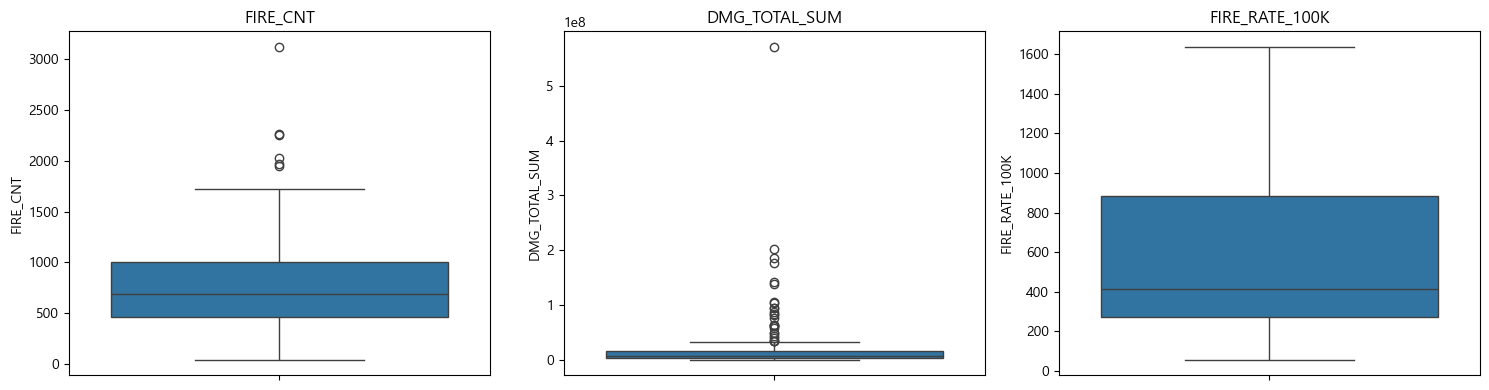

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['FIRE_CNT', 'DMG_TOTAL_SUM', 'FIRE_RATE_100K']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 2.1-4 변수간 상관분석 (Spearman)
- 카운트·금액 변수가 치우쳐 있으므로 순위 기반 상관계수를 사용한다.

                FIRE_CNT  DEATH_CNT  INJURY_CNT  DMG_TOTAL_SUM  POP_AVG_5YR  \
FIRE_CNT           1.000      0.651       0.759          0.475        0.771   
DEATH_CNT          0.651      1.000       0.598          0.421        0.502   
INJURY_CNT         0.759      0.598       1.000          0.437        0.732   
DMG_TOTAL_SUM      0.475      0.421       0.437          1.000        0.240   
POP_AVG_5YR        0.771      0.502       0.732          0.240        1.000   
FIRE_RATE_100K    -0.280     -0.183      -0.424          0.076       -0.794   

                FIRE_RATE_100K  
FIRE_CNT                -0.280  
DEATH_CNT               -0.183  
INJURY_CNT              -0.424  
DMG_TOTAL_SUM            0.076  
POP_AVG_5YR             -0.794  
FIRE_RATE_100K           1.000  


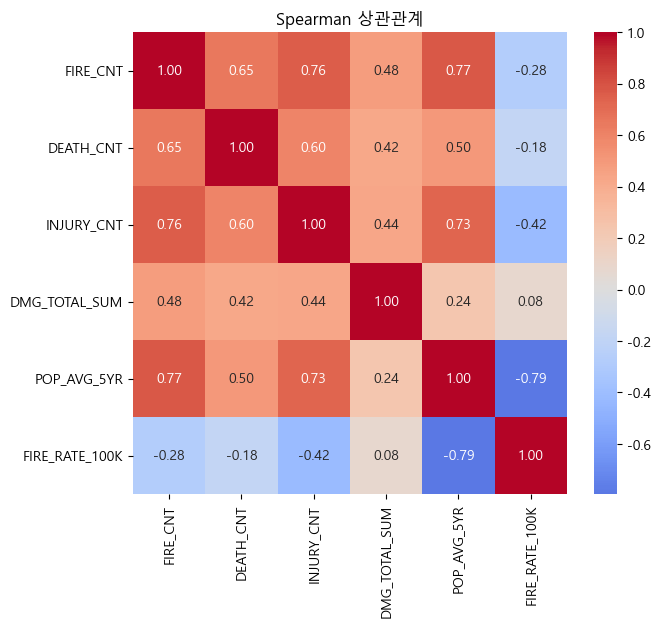

In [15]:
corr = df[num_cols].corr(method='spearman')
print(corr.round(3))

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman 상관관계')
plt.show()

## 2.1 데이터 탐색 결과 해석

**분포 형태**
- FIRE_CNT(왜도 1.40), INJURY_CNT(1.32)는 중간 정도로 치우쳐 있고, DEATH_CNT(4.26)·DMG_TOTAL_SUM(8.34)은 매우 심하게 치우쳐 있다.
- FIRE_RATE_100K(0.77)는 인구로 나눈 것만으로 왜도가 크게 줄고 IQR 이상치도 0개 — 인구 대비 비율로 정규화하면 분포가 훨씬 안정된다.
- 다만 이는 FIRE_RATE_100K를 회귀분석의 종속변수로 직접 쓰라는 뜻은 아니다. 카운트(FIRE_CNT)를 종속변수로, 인구를 오프셋(offset)으로 넣는 포아송/음이항 회귀가 이 데이터 구조에 더 적합하다.

**이상치**
- FIRE_CNT 상위 이상치(화성시·김해시·평택시·강남구 등)는 전부 대도시/신도시로, 규모효과로 설명 가능한 정상적인 값이다.
- DMG_TOTAL_SUM 이상치는 26개(전체의 10%)로 유독 많다. 최댓값인 이천시(5,710억원)는 2021년 대형 물류센터 화재 단일 사건(약 4,743억원, 이천시 5년 피해의 약 83%)이 대부분을 차지한다. 즉 DMG_TOTAL_SUM은 "그 지역이 화재에 취약해서"보다 "대형 사업장 화재가 있었는지 여부"에 좌우된다.

**상관관계 (Spearman)**
- FIRE_CNT ~ POP_AVG_5YR: 0.771 — 인구가 많을수록 화재건수도 많다(규모효과). 모델링 시 인구를 오프셋으로 다루는 근거가 된다.
- POP_AVG_5YR ~ FIRE_RATE_100K: -0.794 — 인구가 많을수록 인구당 화재율은 낮다. 다만 FIRE_RATE_100K는 POP_AVG_5YR을 분모로 계산된 비율이라, 분모 자체와의 상관은 어느 정도 계산구조상 발생하는 부분(허위상관)이 섞여 있을 수 있어 해석에 주의가 필요하다.
- DMG_TOTAL_SUM ~ FIRE_RATE_100K: 0.076 (유의하지 않음, p=0.23) — 피해액은 발생빈도와 무관하다. 위 이천시 사례와 일치.

**변수 역할 정리 (2.2 - 1차 변수선택)**
- DEATH_CNT, INJURY_CNT, DMG_TOTAL_SUM은 화재의 "원인"이 아니라 "결과"이므로 FIRE_CNT를 설명하는 예측변수로 사용하지 않는다. (별도의 종속변수 후보로 보류)
- POP_AVG_5YR은 예측변수가 아니라 노출량(오프셋)으로 사용한다.

### 2.3 파생변수 생성 - 원인·장소·계절 구성비
- 사건 단위 원자료에서 시군구별 구성비를 계산해 분석 테이블에 병합한다.

In [16]:
fire = pd.read_csv(r'C:\data\소방청_화재발생_정보_20241231.csv', encoding='cp949')
fire['화재발생년원일'] = pd.to_datetime(fire['화재발생년원일'])
fire = fire.drop_duplicates().reset_index(drop=True)
fire['시군구'] = fire['시군구'].str.replace(' ', '', regex=False)
fire['월'] = fire['화재발생년원일'].dt.month

deriv = (
    fire.groupby(['시도', '시군구'])
    .apply(lambda g: pd.Series({
        '부주의화재비율': (g['발화요인대분류'] == '부주의').mean(),
        '주거시설화재비율': (g['장소대분류'] == '주거').mean(),
        '동절기화재비율': g['월'].isin([12, 1, 2]).mean()
    }),include_groups=False)
    .round(4)
    .reset_index()
    .rename(columns={'시도': 'SIDO', '시군구':'SIGUNGU'})
)
print(deriv.shape)
print(deriv.describe())

(254, 5)
          부주의화재비율    주거시설화재비율     동절기화재비율
count  254.000000  254.000000  254.000000
mean     0.474611    0.275271    0.277433
std      0.086559    0.085475    0.028676
min      0.069800    0.088600    0.152900
25%      0.407450    0.213700    0.259325
50%      0.475950    0.260200    0.273700
75%      0.533275    0.323650    0.297900
max      0.699200    0.543300    0.362100


In [17]:
df = df.merge(deriv, on=['SIDO', 'SIGUNGU'], how='left')
print('병합 후 결측 :\n', df[['부주의화재비율','주거시설화재비율','동절기화재비율']].isnull().sum())

병합 후 결측 :
 부주의화재비율     0
주거시설화재비율    0
동절기화재비율     0
dtype: int64


In [18]:
fire['월'] = fire['화재발생년원일'].dt.month  # 위 파생변수 계산에 쓴 것과 동일

rename_map = {
    '화재발생년원일': 'FIRE_DT', '시도': 'SIDO', '시군구': 'SIGUNGU',
    '화재유형': 'FIRE_TYPE', '발화요인대분류': 'CAUSE_L', '발화요인소분류': 'CAUSE_S',
    '인명피해(명)소계': 'CASUALTY', '사망': 'DEATH', '부상': 'INJURY',
    '재산피해소계': 'DMG_TOTAL', '부동산': 'DMG_REAL', '동산': 'DMG_MOVABLE',
    '장소대분류': 'PLACE_L', '장소중분류': 'PLACE_M', '장소소분류': 'PLACE_S',
    '월': 'FIRE_MONTH'
}
fire.rename(columns=rename_map).to_csv(
    r'C:\data\fire_clean_for_sas.csv', index=False, encoding='utf-8-sig'
)

### 2.3 파생변수 결과 해석

**전국 평균과의 검증**
- 부주의화재비율 평균 47.46%, 주거시설화재비율 평균 27.53% — 전체 원자료의 전국 비율(부주의 47.5%, 주거 27.3%)과 거의 일치한다. 다만 이 둘은 계산 방식이 다르다는 점에 주의: describe()의 평균은 254개 시군구 비율의 **단순평균**이고, 전국 비율은 전체 건수의 **가중평균**이다. 두 값이 우연히 비슷하게 나온 것이지, 항상 같을 필요는 없다.

**동절기화재비율의 낮은 변동성**
- 표준편차가 0.029로 다른 두 변수(0.087, 0.085)보다 훨씬 작다. 계절성 자체는 전국적으로 비슷하게 나타나고, 지역 간 차이는 크지 않다는 뜻 — 이 변수는 지역 간 화재건수 차이를 설명하는 힘이 약할 수 있다. 제거하지는 않되, 이후 회귀분석에서 유의성을 유심히 봐야 한다.

**부주의화재비율 최저/최고 지역**
- 최저는 울릉군(7.0%)으로, 나머지 지역과 확연히 떨어져 있다. 원인을 보면 전기적 요인(46.5%)·미상(37.2%)이 대신 높다. 다만 울릉군은 5년간 화재건수가 43건으로 데이터에서 가장 적은 지역이라, 비율 추정 자체가 표본이 작아 불안정할 가능성이 있다 — 표본크기가 작은 지역의 비율변수는 변동성이 커진다는 점을 염두에 둬야 한다.
- 최고는 보성군·남해군·순창군·하동군(전남·경남 농촌지역, 60~70%)으로, 봄철 소각 등 농촌형 부주의화재 패턴과 일치한다. 우연이 아니라 정책적으로 의미 있는 패턴일 가능성이 높다.

### 2.4 다중공선성 점검 (상관분석 + VIF)

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

pred_cols = ['부주의화재비율', '주거시설화재비율', '동절기화재비율', 'POP_AVG_5YR']

print(df[pred_cols].corr(method='spearman').round(3))

X = sm.add_constant(df[pred_cols])
vif = pd.DataFrame({
    '변수': pred_cols,
    'VIF': [variance_inflation_factor(X.values, i+1) for i in range(len(pred_cols))]
})
print(vif)

             부주의화재비율  주거시설화재비율  동절기화재비율  POP_AVG_5YR
부주의화재비율        1.000     0.108   -0.160       -0.110
주거시설화재비율       0.108     1.000   -0.226        0.365
동절기화재비율       -0.160    -0.226    1.000       -0.218
POP_AVG_5YR   -0.110     0.365   -0.218        1.000
            변수       VIF
0      부주의화재비율  1.066346
1     주거시설화재비율  1.226575
2      동절기화재비율  1.068828
3  POP_AVG_5YR  1.206730


### 2.4~2.5 다중공선성 점검 및 최종 변수선택

**VIF 결과 — 문제 없음**
- 부주의화재비율 1.07 / 주거시설화재비율 1.23 / 동절기화재비율 1.07 / POP_AVG_5YR 1.21
- 모두 기준선(5 또는 10)에 크게 못 미쳐 다중공선성 문제 없음. 제거 변수 없음.
- 예측변수 간 최대 상관도 주거시설화재비율~POP_AVG_5YR의 0.365 수준으로, 인구가 많은 지역일수록 주거시설 화재 비중이 높다는 관계는 있으나 공선성을 일으킬 정도는 아니다.

**참고 — VIF 산출용 OLS에서 관찰된 것**
- 동절기화재비율의 p값이 0.102로 비유의. 2.3에서 예상했던 "지역 간 변동이 작아 설명력이 약할 것"이라는 점과 일치한다.
- 단, 이 OLS는 VIF 계산 목적으로 돌린 것이며 카운트 데이터에 적합한 모델이 아니므로 계수 해석은 하지 않는다. 변수 유지 여부의 최종 판단은 4단계 포아송/음이항 회귀에서 한다.

**최종 변수 확정**
| 역할 | 변수 |
|---|---|
| 종속변수 | FIRE_CNT |
| 오프셋(노출량) | POP_AVG_5YR |
| 예측변수 | 부주의화재비율, 주거시설화재비율, 동절기화재비율 |
| 분석 제외(결과변수) | DEATH_CNT, INJURY_CNT, DMG_TOTAL_SUM |

### 3.1 정규성 검정
- 이후 그룹 비교에서 모수검정(t검정/ANOVA)과 비모수검정 중 무엇을 쓸지 결정한다.

In [20]:
from scipy import stats

for col in ['FIRE_CNT', 'FIRE_RATE_100K']:
    w, p = stats.shapiro(df[col])
    print(f'{col:16s} W={w:.4f}, p={p:.4g} -> {"정규성 기각" if p < 0.05 else "정규성 유지"}')

FIRE_CNT         W=0.9174, p=1.18e-10 -> 정규성 기각
FIRE_RATE_100K   W=0.8959, p=3.123e-12 -> 정규성 기각


### 3.2 군지역 vs 시·구지역 화재발생율 차이 (Mann-Whitney U)

In [24]:
df['REGION_TYPE'] = np.where(df['SIGUNGU'].str.endswith('군'), '군지역', '시구지역')
print(df['REGION_TYPE'].value_counts()) # 군 83, 시구 171이 정상

g_gun = df.loc[df['REGION_TYPE'] == '군지역', 'FIRE_RATE_100K']
g_sigu = df.loc[df['REGION_TYPE'] == '시구지역', 'FIRE_RATE_100K']

u, p = stats.mannwhitneyu(g_gun, g_sigu, alternative='two-sided')
print(f'\nU={u:.1f}, p={p:.4f}')
print(df.groupby('REGION_TYPE')['FIRE_RATE_100K'].agg(['count', 'median', 'mean']).round(2))

REGION_TYPE
시구지역    171
군지역      83
Name: count, dtype: int64

U=13634.0, p=0.0000
             count   median     mean
REGION_TYPE                         
군지역             83  1017.06  1003.36
시구지역           171   320.37   372.99


### 3.3 시도별 화재발생율 차이 (Kruskal-Wallis)
- 그룹이 3개 이상일 때 사용하는 비모수 검정.

In [26]:
groups = [g['FIRE_RATE_100K'].values for _, g in df.groupby('SIDO')]
h, p = stats.kruskal(*groups)
print(f'H={h:.3f}, p={p:.4g}')
print(df.groupby('SIDO')['FIRE_RATE_100K'].median().sort_values(ascending=False).round(1))

H=117.735, p=1.495e-17
SIDO
전라남도       1059.2
전북특별자치도     990.6
강원특별자치도     891.1
경상북도        818.1
경상남도        800.3
충청남도        669.1
충청북도        544.2
제주특별자치도     492.6
부산광역시       365.1
대전광역시       316.4
울산광역시       308.6
광주광역시       275.2
경기도         271.0
서울특별시       267.1
대구광역시       256.6
인천광역시       220.4
세종특별자치시     140.5
Name: FIRE_RATE_100K, dtype: float64


### 3.4 발화요인 × 장소 독립성 검정 (카이제곱)
- 범주형 변수 두 개의 연관성을 보는 검정. 표본이 크면 p값은 거의 항상 유의하게 나오므로,
효과크기(Cramér's V)를 함께 봐야 한다.

In [27]:
ct = pd.crosstab(fire['발화요인대분류'], fire['장소대분류'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f'chi2={chi2:,.1f}, dof={dof}, p={p:.4f}')
print(f"Cramér's V = {cramers_v:.3f}")
print(f'기대빈도 5미만 셀 비율 : {(expected < 5).mean():.1%}')

chi2=59,050.3, dof=154, p=0.0000
Cramér's V = 0.167
기대빈도 5미만 셀 비율 : 12.2%


### 3.5 과산포(overdispersion) 확인
- 포아송 분포는 평균=분산을 가정한다. 분산이 평균보다 훨씬 크면 음이항 회귀가 필요하다.

In [28]:
m, v = df['FIRE_CNT'].mean(), df['FIRE_CNT'].var()
print(f'평균={m:.2f}, 분산={v:.2f}, 분산/평균={v/m:.2f}')

평균=753.97, 분산=184499.62, 분산/평균=244.70
